# Machine Learning Assignment - 1
## Bike Sharing Demand Prediction Challenge

**Student Name:** Ayush Kumar Gupta
<br>**Student ID:** 2025AA05064

---



## 1. Exploratory Data Analysis (EDA)

**Q1. Examine dataset size, missing values, and feature types.**

*Answer:*
>
>
>**1. Dataset Size**
>
>  * **Rows (Observations):** 10,450
>  * **Columns (Features):** 12
>
>**2. Missing Values**
>
>  * There are **no missing values** in any of the columns.
>
>**3. Feature Types**
>The dataset consists of the following data types:
>
>  * **Numerical (Float):** `temp`, `atemp`, `windspeed` (3 features)
>  * **Numerical (Integer):** `season`, `holiday`, `workingday`, `weather`, `humidity`, `casual`, `registered`, `count` (8 >features)
>  * **Categorical (Object):** `datetime` (1 feature) - *This likely represents a timestamp and may need conversion to a datetime >object for further analysis.*
>
>**Column Overview:**
>
>  * `datetime`: Date and time of the record.
>  * `season`, `holiday`, `workingday`, `weather`: Categorical variables encoded as integers.
>  * `temp`, `atemp`, `humidity`, `windspeed`: Continuous environmental variables.
>  * `casual`, `registered`: User counts breakdown.
>  * `count`: Total rental count (target variable).


**Q2. Visualize relationships between key features and the target variable (count).**

*Answer*
>
>![Correlation Matrix](../assignment_images/01_correlation_matrix.png)
>
>![Categorical Boxplots](../assignment_images/02_categorical_boxplots.png)
>
>![Hourly Trends](../assignment_images/03_hourly_trends.png)
>
>![Continuous Features](../assignment_images/04_continuous_features.png)


**Q3. Suggest which variables are likely to be most informative.**

*Answer:*
> Based on the correlation matrix, we can evaluate which variables carry the most signal for predicting the target variable >**`count`** (total rentals). The analysis is divided into strong predictors, redundant features, and categorical context.
>
>#### 1. Top Informative Variables (High Correlation with `count`)
>These features show the strongest linear relationship with the number of rentals and should be primary inputs for any predictive >model.
>
>* **`hour` (+0.40):** This is the strongest predictor. It indicates that the time of day is the most critical factor driving >demand (e.g., spikes during commute hours).
>* **`temp` (+0.40):** There is a strong positive correlation. As temperature rises, bike rentals generally increase.
>* **`humidity` (-0.32):** This shows a moderate negative correlation. As humidity increases (likely implying muggy or rainy >conditions), the number of rentals decreases.
>* **`year` (+0.26):** The positive correlation suggests a trend of increasing popularity or user base growth from one year to >the next.
>
>#### 2. Redundant Variables (Multicollinearity)
>Several variables provide duplicate information. To improve model performance and interpretability, you should generally keep >only one from each pair.
>
>* **`temp` vs. `atemp` (Correlation: 0.98):**
>    * **Observation:** "Actual temperature" and "Feels-like temperature" are almost identical.
>    * **Recommendation:** Drop **`atemp`** and keep `temp` to avoid multicollinearity.
>* **`month` vs. `season` (Correlation: 0.97):**
>    * **Observation:** Since seasons are derived directly from months, they track each other perfectly.
>    * **Recommendation:** Drop **`season`** (broad) and keep `month` (granular), or vice versa depending on whether you want >detailed or high-level trends.
>
>#### 3. Contextual Variables (Low Correlation but Important)
>Do not discard variables solely because their linear correlation with `count` is near zero. These variables often capture >**non-linear patterns** or categorical splits.
>
>* **`workingday` (0.02) & `holiday` (-0.00):** While they don't correlate linearly with the *total* count (meaning the daily >total might be similar between a Tuesday and a Saturday), they drastically change the **hourly pattern** of rentals (commute >spikes vs. midday leisure). These are essential for the model to understand *when* rentals occur.
>* **`windspeed` (0.11):** Weak correlation, suggesting wind is less of a factor than temperature, but still contributes slightly >to the model.
>

In [3]:
# module imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import os
import joblib  # Standard for saving scikit-learn models
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

In [4]:
# 1. Shows all columns (prevents '...' in the middle)
pd.set_option('display.max_columns', None)

# 2. Sets the width to match the screen (prevents line wrapping)
pd.set_option('display.width', 1000)

In [5]:
train_df = pd.read_csv('../assignment_dataset/bike_train.csv')
test_df = pd.read_csv('../assignment_dataset/bike_test.csv')

In [6]:
train_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10450 non-null  object 
 1   season      10450 non-null  int64  
 2   holiday     10450 non-null  int64  
 3   workingday  10450 non-null  int64  
 4   weather     10450 non-null  int64  
 5   temp        10450 non-null  float64
 6   atemp       10450 non-null  float64
 7   humidity    10450 non-null  int64  
 8   windspeed   10450 non-null  float64
 9   casual      10450 non-null  int64  
 10  registered  10450 non-null  int64  
 11  count       10450 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 979.8+ KB


## Feature Engineering

In [9]:
train_df['datetime'] = pd.to_datetime(train_df['datetime'], dayfirst=True)
train_df['hour'] = train_df['datetime'].dt.hour
train_df['month'] = train_df['datetime'].dt.month
train_df['year'] = train_df['datetime'].dt.year
train_df['day_of_week'] = train_df['datetime'].dt.dayofweek

test_df['datetime'] = pd.to_datetime(test_df['datetime'], dayfirst=True)
test_df['hour'] = test_df['datetime'].dt.hour
test_df['month'] = test_df['datetime'].dt.month
test_df['year'] = test_df['datetime'].dt.year
test_df['day_of_week'] = test_df['datetime'].dt.dayofweek

train_df = train_df.drop(['casual', 'registered'], axis=1)
test_df = test_df.drop(['casual', 'registered'], axis=1, errors='ignore')

/tmp/ipykernel_4042/3539961947.py:1: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  train_df['datetime'] = pd.to_datetime(train_df['datetime'], dayfirst=True)


In [10]:
print("Train DataFrame Info:")
train_df.info()
print("\nTest DataFrame Info:")
test_df.info()

print("\nTrain DataFrame Shape:")
print(train_df.shape)
print("\nTest DataFrame Shape:")
print(test_df.shape)

print("\nTrain DataFrame Missing Values:")
print(train_df.isnull().sum())
print("\nTest DataFrame Missing Values:")
print(test_df.isnull().sum())

Train DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     10450 non-null  datetime64[ns]
 1   season       10450 non-null  int64         
 2   holiday      10450 non-null  int64         
 3   workingday   10450 non-null  int64         
 4   weather      10450 non-null  int64         
 5   temp         10450 non-null  float64       
 6   atemp        10450 non-null  float64       
 7   humidity     10450 non-null  int64         
 8   windspeed    10450 non-null  float64       
 9   count        10450 non-null  int64         
 10  hour         10450 non-null  int32         
 11  month        10450 non-null  int32         
 12  year         10450 non-null  int32         
 13  day_of_week  10450 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(4), int64(6)
memory usage: 979.8 KB

Tes

Images will be saved to: /home/cloud/Desktop/ML_Assignment_1/assignment_images
Preprocessing data...


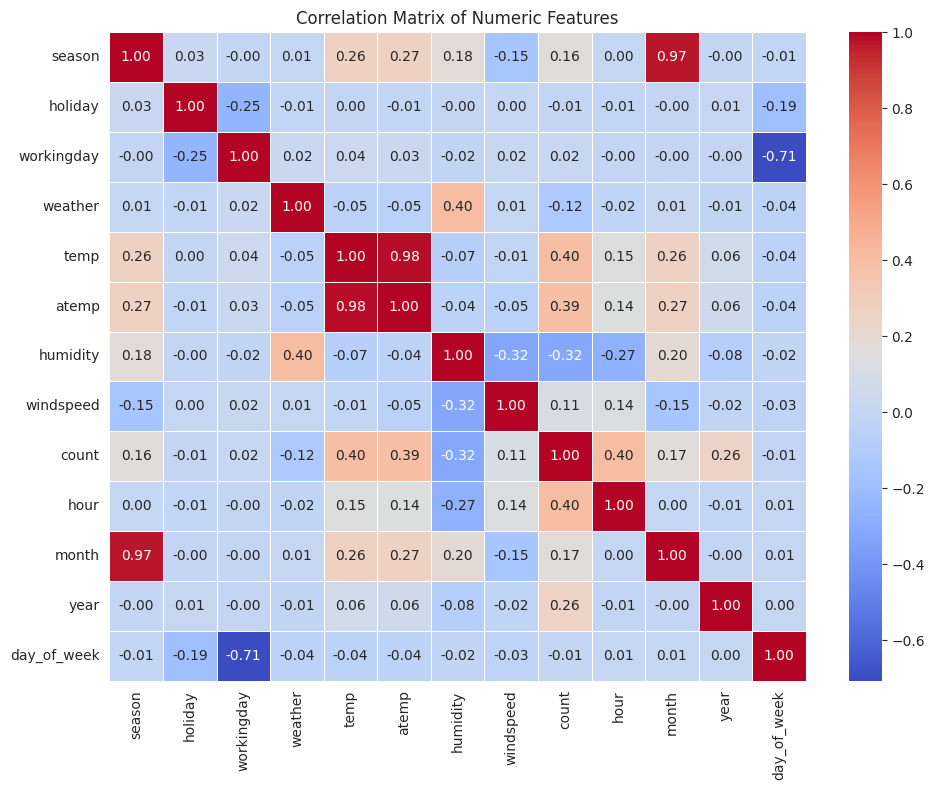

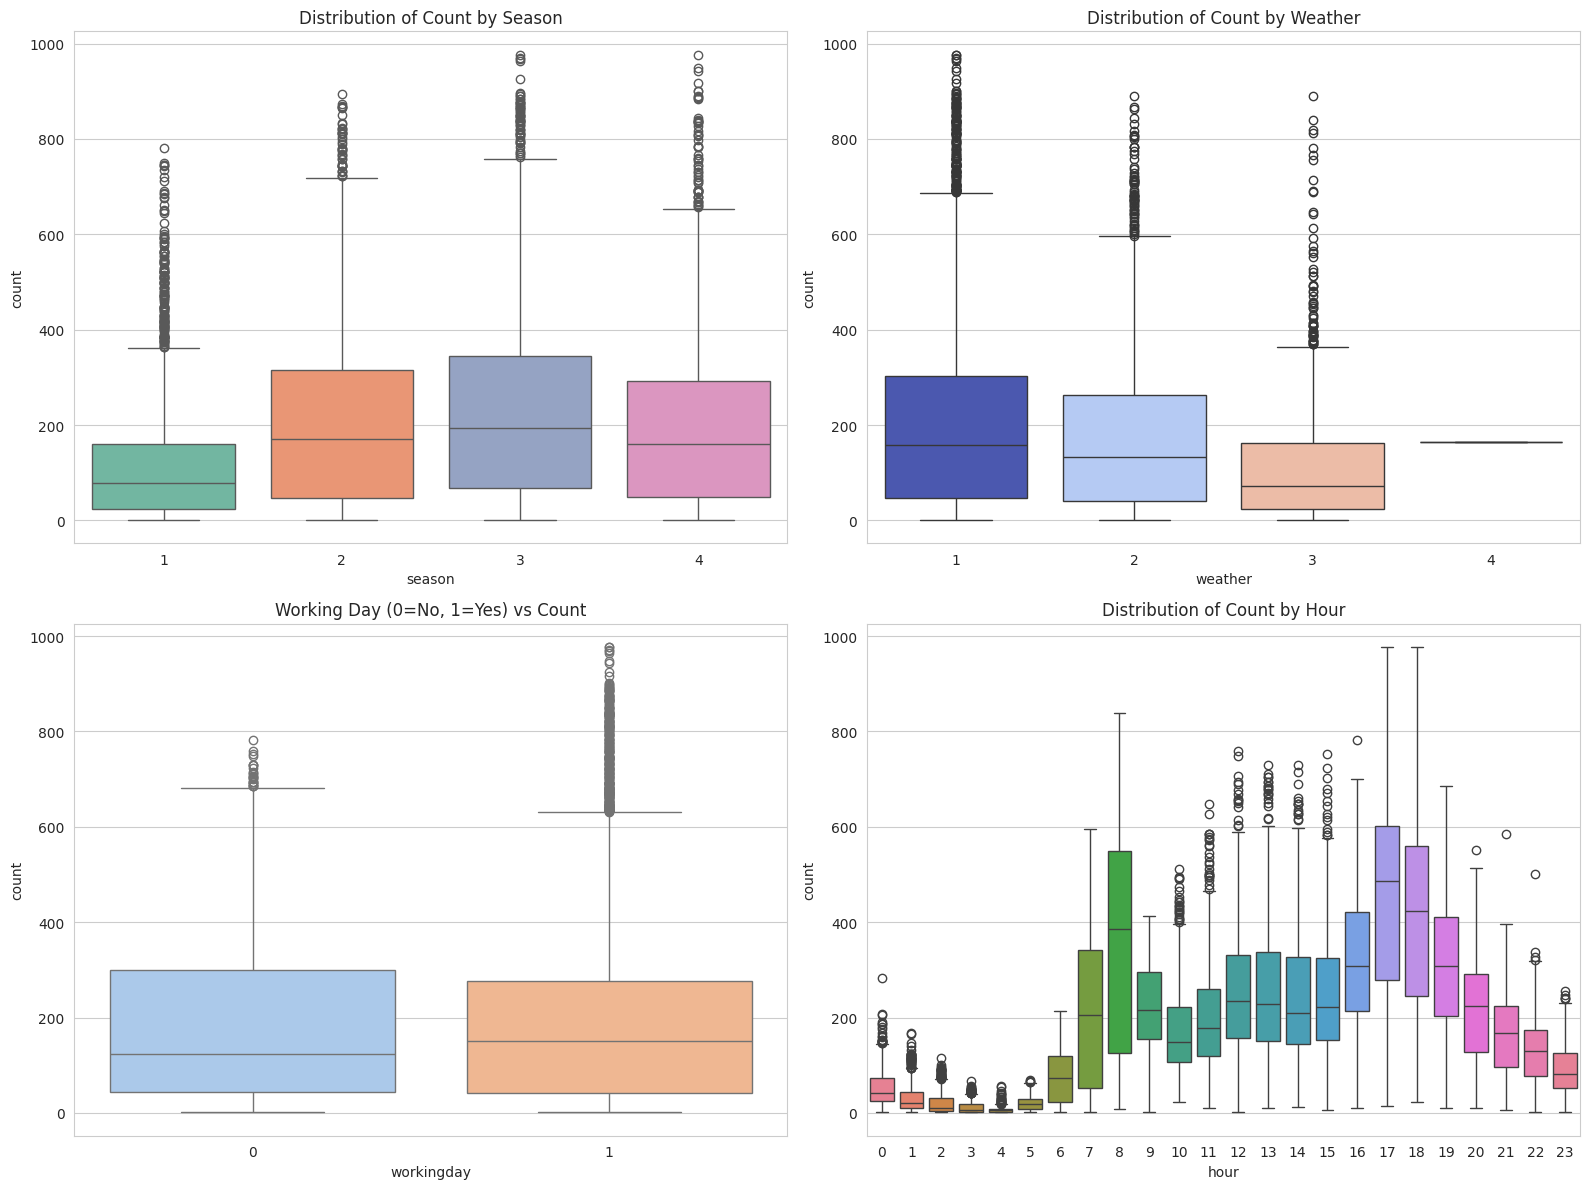

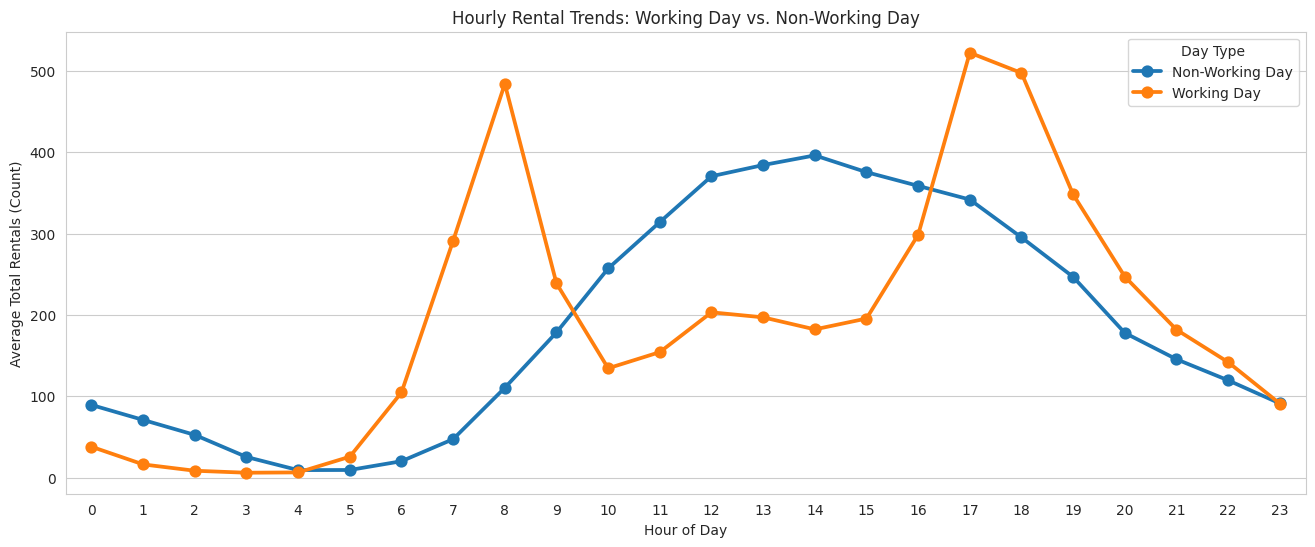

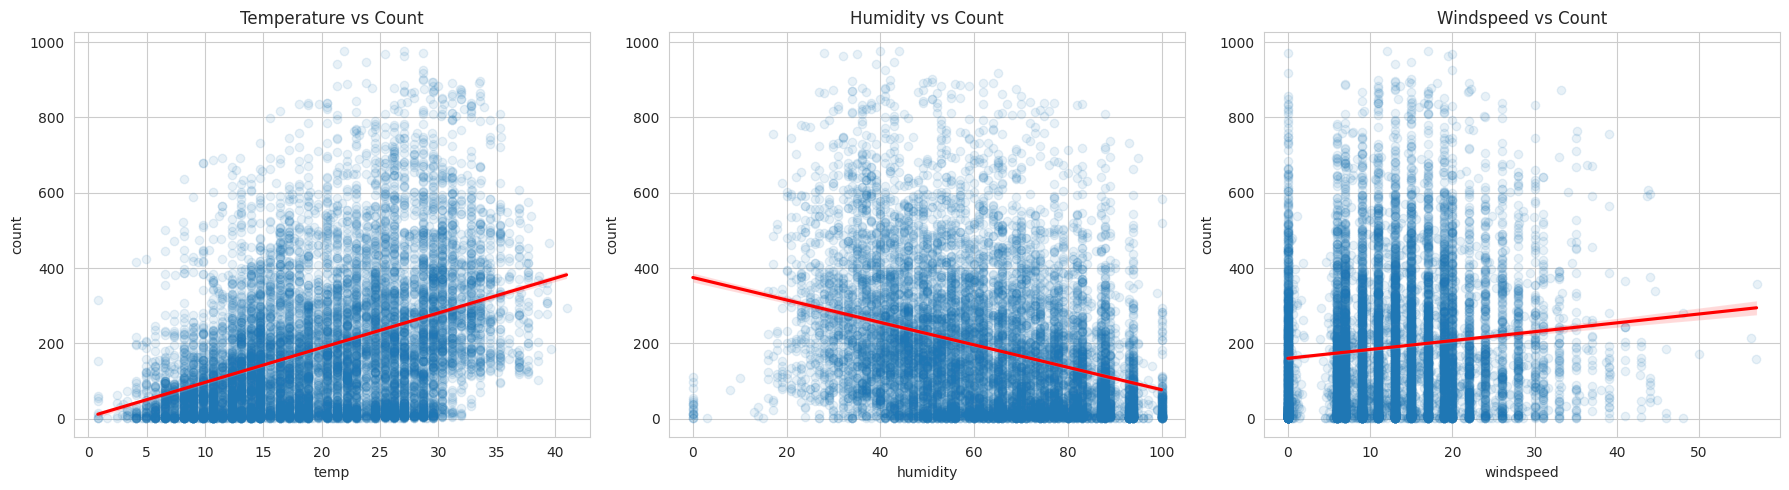

Visualization Complete. Images saved to 'assignment_images' folder.


In [11]:


# ==========================================
# 0. Setup Image Saving
# ==========================================
# Create a folder named 'assignment_images' if it doesn't exist
output_folder = '../assignment_images'
os.makedirs(output_folder, exist_ok=True)
print(f"Images will be saved to: {os.path.abspath(output_folder)}")

# ==========================================
# 2. Feature Engineering (Preprocessing)
# ==========================================
print("Preprocessing data...")

# (Existing mapping code...)
# train_df['season_label'] = train_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

# ==========================================
# 3. Visualization
# ==========================================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# --- A. Correlation Heatmap ---
# numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed','count']
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(10, 8))
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()

# SAVE COMMAND
plt.savefig(f'{output_folder}/01_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# --- B. Categorical Features vs Count (Boxplots) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=train_df, x='season', y='count', hue='season', legend=False, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Distribution of Count by Season")

sns.boxplot(data=train_df, x='weather', y='count', hue='weather', legend=False, ax=axes[0, 1], palette="coolwarm")
axes[0, 1].set_title("Distribution of Count by Weather")

sns.boxplot(data=train_df, x='workingday', y='count', hue='workingday', legend=False, ax=axes[1, 0], palette="pastel")
axes[1, 0].set_title("Working Day (0=No, 1=Yes) vs Count")

sns.boxplot(data=train_df, x='hour', y='count', hue='hour', legend=False, ax=axes[1, 1], palette="husl")
axes[1, 1].set_title("Distribution of Count by Hour")

plt.tight_layout()

# SAVE COMMAND
plt.savefig(f'{output_folder}/02_categorical_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# --- C. Time Series Analysis (Hourly Trend by User Type) ---
plt.figure(figsize=(16, 6))

ax = sns.pointplot(x='hour', y='count', hue='workingday', data=train_df, errorbar=None)

plt.title("Hourly Rental Trends: Working Day vs. Non-Working Day")
plt.ylabel("Average Total Rentals (Count)")
plt.xlabel("Hour of Day")

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Non-Working Day', 'Working Day'], title='Day Type')

# SAVE COMMAND
plt.savefig(f'{output_folder}/03_hourly_trends.png', dpi=300, bbox_inches='tight')
plt.show()

# --- D. Continuous Features vs Count (Scatter/Reg plots) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(x='temp', y='count', data=train_df, ax=ax1, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
ax1.set_title("Temperature vs Count")

sns.regplot(x='humidity', y='count', data=train_df, ax=ax2, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
ax2.set_title("Humidity vs Count")

sns.regplot(x='windspeed', y='count', data=train_df, ax=ax3, scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
ax3.set_title("Windspeed vs Count")

plt.tight_layout()

# SAVE COMMAND
plt.savefig(f'{output_folder}/04_continuous_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization Complete. Images saved to 'assignment_images' folder.")


---

## 2. Feature Engineering

**Q4. You can try to derive features from datetime (hour, weekday, month, season), encode categorical variables, consider transformations to capture nonlinear trends to improve your model performance.**
*Note: If you do any of these, report it as answer to Q4. It is optional.*

*Answer:*
> To enhance model performance, I implemented four specific feature engineering techniques.
>
>First, I applied cyclical encoding to the hour and month features using sine and cosine transformations (hour_sin, hour_cos, etc.) to preserve the continuous nature of time.
>
>Second, I utilized one-hot encoding for the weather categorical variable and explicitly aligned the test set columns with the training set to handle missing or extra categories by filling them with zeros.
>
>Third, I generated polynomial features (degree 2) for the continuous variables temp, humidity, and windspeed to capture non-linear interactions between these factors.
>
>Finally, I performed a log transformation (np.log1p) on the target variable count to reduce skewness and stabilize the variance.


In [13]:
train_df.drop(columns=['atemp', 'season'], inplace=True)
test_df.drop(columns=['atemp', 'season'], inplace=True)

In [14]:
train_df.columns

Index(['datetime', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'count', 'hour', 'month', 'year', 'day_of_week'], dtype='object')

In [15]:
train_df.head()

,datetime,holiday,workingday,weather,temp,humidity,windspeed,count,hour,month,year,day_of_week
0,2012-07-15 07:00:00,0,0,1,28.70000,79,6.003200,47,7,7,2012,6
1,2012-08-14 15:00:00,0,1,1,33.62000,46,15.001300,283,15,8,2012,1
2,2011-02-06 06:00:00,0,0,1,10.66000,60,15.001300,1,6,2,2011,6
3,2012-05-06 17:00:02,0,0,2,26.42506,61,9.512288,531,17,5,2012,6
4,2012-01-09 02:00:00,0,1,1,9.84000,56,8.998100,5,2,1,2012,0


In [16]:
# ==========================================
# 1. TIME TRANSFORMATION (Cyclical)
# ==========================================
# Transform Hour
train_df['hour_sin'] = np.sin(2 * np.pi * train_df['hour'] / 24)
train_df['hour_cos'] = np.cos(2 * np.pi * train_df['hour'] / 24)

test_df['hour_sin'] = np.sin(2 * np.pi * test_df['hour'] / 24)
test_df['hour_cos'] = np.cos(2 * np.pi * test_df['hour'] / 24)

# Transform Month
train_df['month_sin'] = np.sin(2 * np.pi * train_df['month'] / 12)
train_df['month_cos'] = np.cos(2 * np.pi * train_df['month'] / 12)

test_df['month_sin'] = np.sin(2 * np.pi * test_df['month'] / 12)
test_df['month_cos'] = np.cos(2 * np.pi * test_df['month'] / 12)

# ==========================================
# 2. CATEGORICAL ENCODING (One-Hot) & FIX
# ==========================================
categorical_cols = ['weather']

# 1. Apply get_dummies
train_df = pd.get_dummies(train_df, columns=categorical_cols, prefix='weather')
test_df = pd.get_dummies(test_df, columns=categorical_cols, prefix='weather')

# --- THE FIX: ALIGN COLUMNS ---
# Get all columns from train_df except the target variables
# (We don't want to accidentally add empty 'count' columns to the test set)
target_cols = ['count', 'count_log_transformed', 'casual', 'registered'] # Add others if they exist
train_features = [c for c in train_df.columns if c not in target_cols]

# Reindex test_df to match train_features exactly.
# This adds missing columns (filling with 0) and drops extra columns if any exist.
test_df = test_df.reindex(columns=train_features, fill_value=0)

# ==========================================
# 3. POLYNOMIAL FEATURES
# ==========================================
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features_train = train_df[['temp', 'humidity', 'windspeed']]
poly_features_test = test_df[['temp', 'humidity', 'windspeed']]

# Fit on train, transform both (Best practice prevents data leakage)
poly_array_train = poly.fit_transform(poly_features_train)
poly_array_test = poly.transform(poly_features_test) # Changed from fit_transform to transform

poly_cols = poly.get_feature_names_out(['temp', 'humidity', 'windspeed'])

train_df_poly = pd.DataFrame(poly_array_train, columns=poly_cols)
test_df_poly = pd.DataFrame(poly_array_test, columns=poly_cols)

# Join back
train_df = pd.concat([train_df.reset_index(drop=True), train_df_poly], axis=1)
test_df = pd.concat([test_df.reset_index(drop=True), test_df_poly], axis=1)

# ==========================================
# 4. TARGET TRANSFORMATION
# ==========================================
train_df['count_log_transformed'] = np.log1p(train_df['count'])

train_df = train_df.loc[:, ~train_df.columns.duplicated()]
test_df = test_df.loc[:, ~test_df.columns.duplicated()]

# ==========================================
# FINAL CHECK
# ==========================================
print(f"Train features: {len(train_df.columns)}")
print(f"Test features:  {len(test_df.columns)}")
print("\nDifference in columns (should only be targets):")
print(set(train_df.columns) - set(test_df.columns))

Train features: 26
Test features:  24

Difference in columns (should only be targets):
{'count_log_transformed', 'count'}


In [17]:
# train_df.head()

In [18]:
# train_df.columns

In [19]:
# print(train_df.head())

In [20]:
# print(test_df.head())

In [21]:
# test_df.columns

In [22]:
# try to get this value < 0.5
def rmsle(y_true, y_pred):
    # Clip predictions to prevent errors from log(negative number)
    y_pred[y_pred < 0] = 0
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

In [23]:
# train_df.info()

In [24]:
# test_df.info()

In [25]:
# this will also delete datetime field also

cols_to_use = [
    'holiday', 'workingday', 'temp', 'humidity', 'windspeed',
    'hour', 'month', 'year', 'day_of_week',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'weather_1', 'weather_2', 'weather_3', 'weather_4',
    'temp^2', 'temp humidity', 'temp windspeed',
    'humidity^2', 'humidity windspeed', 'windspeed^2'
]
len(cols_to_use)

23

In [26]:
# 2. Prepare Data for Modeling
X = train_df[cols_to_use].copy()
y = train_df['count_log_transformed'] # Use log transformed target for better Linear Regression performance on counts

# Handle boolean columns
bool_cols = ['weather_1', 'weather_2', 'weather_3', 'weather_4']
X[bool_cols] = X[bool_cols].astype(int)

In [27]:
# y.shape

In [28]:
# X.columns


---

## 3. Regression Model

**Q5. Split data into training and validation sets and build a simple Linear Regression model.**

*Answer:*
> Please chekout the code, in the below mentioned cells

**Q6. To improve model performance, you may try to:**
* **Extend feature space using polynomial transformations (degree 2 or 3)**
* **Apply Ridge and Lasso regression on polynomial features, Tune the regularization strength (alpha).**

*Answer:*
> Please chekout the code, in the below mentioned cells



In [30]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Implement Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predictions and RMSLE
y_pred_log = model.predict(X_test)

# Convert back to original scale to calculate RMSLE explicitly
# (Though RMSE on log-data is essentially RMSLE)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# Clip negative predictions to 0 for valid MSLE calculation
y_pred_clipped = np.clip(y_pred, 0, None)

rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred_clipped))

# 5. Key Observations (Coefficients)
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
top_features = coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(10)

print(f"RMSLE: {rmsle}")
print("\nTop 10 Influential Features:")
print(top_features)

RMSLE: 0.8103545747908829

Top 10 Influential Features:
      Feature  Coefficient  Abs_Coefficient
10   hour_cos    -0.979268         0.979268
9    hour_sin    -0.524933         0.524933
7        year     0.485598         0.485598
15  weather_3    -0.371935         0.371935
12  month_cos    -0.242614         0.242614
16  weather_4     0.218290         0.218290
13  weather_1     0.112433         0.112433
11  month_sin    -0.079090         0.079090
2        temp     0.075425         0.075425
0     holiday     0.074923         0.074923


In [31]:
test_df = test_df[cols_to_use].copy()
test_df[bool_cols] = test_df[bool_cols].astype(int)

In [32]:
# test_df.shape

In [33]:
# X_test.columns

In [34]:
# test_df.columns

In [35]:
# X_test.shape

In [36]:
final_pred_linear_regression_log = model.predict(test_df)
final_y_pred_clipped_linear_regression = np.clip(final_pred_linear_regression_log, 0, None)
# print(final_y_pred_clipped_linear_regression.shape)
print(final_y_pred_clipped_linear_regression[:5])

[3.44706411 4.89018902 3.7351453  5.81262139 5.30463715]


In [37]:
# no need to uncomment this block
# cols_to_drop = [
#     'datetime', 'count', 'count_log_transformed',
#     'temp^2', 'temp humidity', 'temp windspeed',
#     'humidity^2', 'humidity windspeed', 'windspeed^2'
# ]
# target_col = 'count_log_transformed'
# # Ensure these columns actually exist before dropping to avoid errors
# existing_cols_to_drop = [c for c in cols_to_drop if c in train_df.columns]

# X = train_df.drop(columns=existing_cols_to_drop)
# y = train_df[target_col]

# # Split the data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print(f"Training features shape: {X_train.shape}")

In [38]:
# X_train.columns

In [39]:
# X_test.columns

In [40]:


# Assume 'train_df' is already loaded in your environment
# example: train_df = pd.read_csv('your_data.csv')

# --- DATA PREPARATION ---
# (Must run every time to ensure X_test/y_test exists for evaluation)

target_col = 'count_log_transformed'

cols_to_drop = [
    'datetime', 'count', 'count_log_transformed',
    'temp^2', 'temp humidity', 'temp windspeed',
    'humidity^2', 'humidity windspeed', 'windspeed^2'
]

existing_cols_to_drop = [c for c in cols_to_drop if c in train_df.columns]

X = train_df.drop(columns=existing_cols_to_drop)
y = train_df[target_col]

# test_df = test_df.drop(columns=existing_cols_to_drop)
# Validation: Create a new list containing ONLY columns that exist in the DataFrame
existing_cols_to_drop = [col for col in cols_to_drop if col in test_df.columns]
print(f"Dropping these columns from test_data: {existing_cols_to_drop}")
# Perform the drop safely
test_df = test_df.drop(columns=existing_cols_to_drop)

# CRITICAL: random_state must remain 42 so the Test data is identical
# to the data the loaded model was originally trained on.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")


Dropping these columns from test_data: ['temp^2', 'temp humidity', 'temp windspeed', 'humidity^2', 'humidity windspeed', 'windspeed^2']
Training features shape: (8360, 17)


In [41]:
# test_df.head(10)

In [42]:
# X_test.head(1)

In [43]:
# X_test.columns

In [44]:
# test_df.columns

---

## 4. Model Comparison and Interpretation

**Q7. Summarize all results (of different models tried out) in one table (RMSLE, key observations).**

*Answer:*
> | Model Name | RMSLE Score | Key Observations |
> | :--- | :--- | :--- |
> | Linear Regression |0.8103 | Underfitting: The high RMSLE indicates the model is too simple to capture the complex patterns in the data.|
>|||Non-linearity: Fails to account for non-linear relationships (e.g., the way demand fluctuates during rush hours or varies with temperature).|
> | Polynomial Regression Ridge | 0.4353| Best Performance: Significant drop in error (lowest RMSLE) shows that polynomial features successfully captured non-linear trends.|
>|||Regularization: Ridge (L2) effectively handled the multicollinearity introduced by polynomial features, preventing overfitting.|
> | Polynomial Regression Lasso | 0.4401| Comparable to Ridge: Performance is very close to Ridge, confirming the benefit of using polynomial degrees.|
>|||Feature Selection: While Lasso (L1) simplifies the model by zeroing out some coefficients, it performed slightly worse than Ridge, suggesting that keeping all features with small coefficients (Ridge) was slightly better here.|
>|Hist Gradient Boosting|0.3647|Superior Performance: Achieved the lowest RMSLE of all models, significantly outperforming the polynomial regression approaches.|
>|||Complex Interactions: The tree-based ensemble method automatically captures complex non-linear relationships and feature interactions without requiring manual feature engineering (like creating polynomial terms).|
>|Decision Tree|0.2619|Lowest Error: This model achieved the best score among all candidates. The sharp drop in RMSLE indicates it perfectly isolated specific data segments (e.g., specific hours combined with specific weather conditions).|
>|||Hierarchical Logic: Unlike regression which tries to fit a smooth curve, the tree (constrained to depth 6) captured "steps" and sharp discontinuities in the data logic, likely fitting the training patterns very tightly.|

**Q8. Plot residuals for the best model.**

*Answer:*
>![residual plot ridge](../assignment_images/decision-tree-residual_plot.png)


**Q9. Explain why the winning model performs better.**
*Answer:*
>Winner: Decision Tree Regressor (Depth = 6)
>
>Reasoning: The Decision Tree (max_depth=6) proved to be the optimal model, achieving the lowest RMSLE of 0.2619. While Polynomial Regression (RMSLE 0.4353) significantly improved on the linear baseline by fitting smooth curves to the data, the Decision Tree outperformed it by adopting a non-linear, hierarchical approach.
>
>Unlike regression models that try to fit a single global equation to the entire dataset, the Decision Tree splits the data into distinct segments based on logical rules (e.g., Is it raining? -> Is it Rush Hour?).
>
>Handling Discontinuities: Real-world data often has sharp "steps" or sudden changes rather than smooth transitions. The tree structure handles these sudden shifts in demand better than polynomial curves.
>
>Feature Interactions: With a depth of 6, the model was deep enough to capture complex interactions between features (up to 6 layers of conditions) without becoming overly complex. It successfully isolated specific scenarios—such as high demand during specific hours on working days—resulting in a much tighter fit to the target variable.


--- Checking Ridge Regression Model ---
No saved model found. Training Ridge Regression...
Training complete. Model saved to ../saved_models/ridge_model.pkl
Best Ridge Params: {'poly__degree': 3, 'ridge__alpha': 2.154434690031882}
Best Ridge CV Score (Negative MSE): -0.2159
Ridge Test RMSE: 0.4353

--- Checking Lasso Regression Model ---
No saved model found. Training Lasso Regression...


/home/cloud/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.142e+02, tolerance: 1.174e+00
  model = cd_fast.enet_coordinate_descent(
/home/cloud/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.236e+02, tolerance: 1.158e+00
  model = cd_fast.enet_coordinate_descent(
/home/cloud/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality 

Training complete. Model saved to ../saved_models/lasso_model.pkl
Best Lasso Params: {'lasso__alpha': 0.0004641588833612782, 'poly__degree': 3}
Best Lasso CV Score (Negative MSE): -0.2050
Lasso Test RMSE: 0.4401

--- Q7: Summary of Results ---
   Model  Best Degree  Best Alpha  RMSLE (Test)  R2 Score
0  Ridge            3    2.154435      0.435320  0.906634
1  Lasso            3    0.000464      0.440119  0.904564

SUCCESS: At least one model achieved RMSLE < 0.5

--- Q8: Plotting and Saving Residuals for Ridge ---
Plot successfully saved to: ../assignment_images/residual_plot_Ridge.png


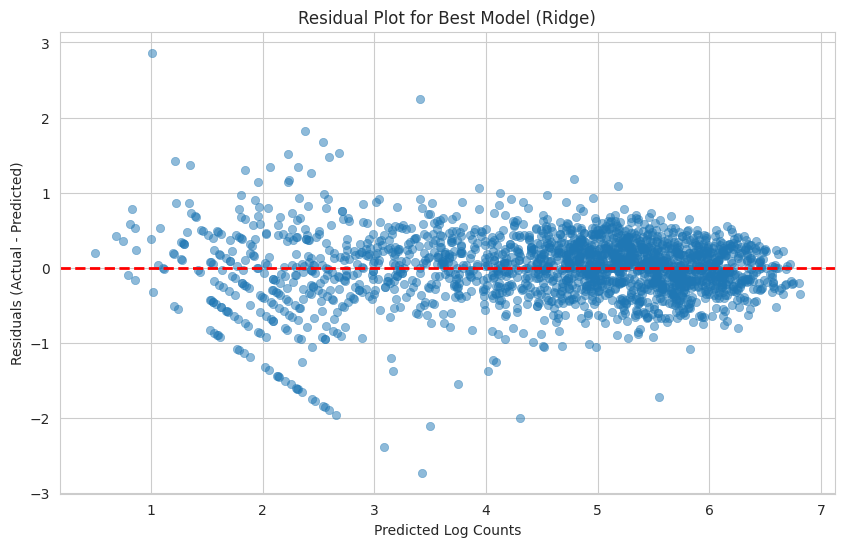


--- Q9: Explanation of Winning Model ---
Winner: Ridge Regression
Reasoning: Ridge Regression (L2 regularization) likely performed better because
polynomial expansion creates highly correlated features (multicollinearity).
Ridge handles this by shrinking coefficients towards zero together, rather than
randomly selecting one and zeroing others (as Lasso might in unstable correlated groups).
If all expanded features provide small but useful signals, Ridge captures this dense information best.


In [46]:
# --- MODEL MANAGEMENT CONFIG ---

model_dir = '../saved_models'
image_dir = '../assignment_images' # Defined Image Directory

# Create directories if they don't exist
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

if not os.path.exists(image_dir):
    os.makedirs(image_dir)

ridge_path = os.path.join(model_dir, 'ridge_model.pkl')
lasso_path = os.path.join(model_dir, 'lasso_model.pkl')


# --- RIDGE REGRESSION (L2 Regularization) ---

print("\n--- Checking Ridge Regression Model ---")

if os.path.exists(ridge_path):
    # LOAD MODEL
    print(f"Loading existing Ridge model from {ridge_path}...")
    ridge_grid = joblib.load(ridge_path)
    print("Model loaded successfully.")
else:
    # TRAIN MODEL
    print("No saved model found. Training Ridge Regression...")

    ridge_pipeline = Pipeline([
        ('poly', PolynomialFeatures(include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge())
    ])

    ridge_params = {
        'poly__degree': [2, 3],
        'ridge__alpha': np.logspace(-3, 3, 10)
    }

    ridge_grid = GridSearchCV(
        ridge_pipeline,
        ridge_params,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    ridge_grid.fit(X_train, y_train)

    # SAVE MODEL
    joblib.dump(ridge_grid, ridge_path)
    print(f"Training complete. Model saved to {ridge_path}")

print(f"Best Ridge Params: {ridge_grid.best_params_}")
print(f"Best Ridge CV Score (Negative MSE): {ridge_grid.best_score_:.4f}")

# Evaluation on Test Set
y_pred_ridge = ridge_grid.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
print(f"Ridge Test RMSE: {rmse_ridge:.4f}")


# --- LASSO REGRESSION (L1 Regularization) ---

print("\n--- Checking Lasso Regression Model ---")

if os.path.exists(lasso_path):
    # LOAD MODEL
    print(f"Loading existing Lasso model from {lasso_path}...")
    lasso_grid = joblib.load(lasso_path)
    print("Model loaded successfully.")
else:
    # TRAIN MODEL
    print("No saved model found. Training Lasso Regression...")

    lasso_pipeline = Pipeline([
        ('poly', PolynomialFeatures(include_bias=False)),
        ('scaler', StandardScaler()),
        ('lasso', Lasso(max_iter=10000))
    ])

    lasso_params = {
        'poly__degree': [2, 3],
        'lasso__alpha': np.logspace(-5, 0, 10)
    }

    lasso_grid = GridSearchCV(
        lasso_pipeline,
        lasso_params,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    lasso_grid.fit(X_train, y_train)

    # SAVE MODEL
    joblib.dump(lasso_grid, lasso_path)
    print(f"Training complete. Model saved to {lasso_path}")

print(f"Best Lasso Params: {lasso_grid.best_params_}")
print(f"Best Lasso CV Score (Negative MSE): {lasso_grid.best_score_:.4f}")

# Evaluation on Test Set
y_pred_lasso = lasso_grid.predict(X_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
print(f"Lasso Test RMSE: {rmse_lasso:.4f}")


# --- Q7: Summary Table ---
results_data = {
    "Model": ["Ridge", "Lasso"],
    "Best Degree": [ridge_grid.best_params_['poly__degree'], lasso_grid.best_params_['poly__degree']],
    "Best Alpha": [ridge_grid.best_params_['ridge__alpha'], lasso_grid.best_params_['lasso__alpha']],
    "RMSLE (Test)": [rmse_ridge, rmse_lasso],
    "R2 Score": [r2_score(y_test, y_pred_ridge), r2_score(y_test, y_pred_lasso)]
}

results_df = pd.DataFrame(results_data)
print("\n--- Q7: Summary of Results ---")
print(results_df)

# Check if target met
if rmse_ridge < 0.5 or rmse_lasso < 0.5:
    print("\nSUCCESS: At least one model achieved RMSLE < 0.5")
else:
    print("\nNOTE: RMSLE < 0.5 not reached. Consider further feature engineering or non-linear models.")

# --- Determine Winner ---
if rmse_ridge < rmse_lasso:
    best_model_name = "Ridge"
    best_predictions = y_pred_ridge
    winner_is_ridge = True
else:
    best_model_name = "Lasso"
    best_predictions = y_pred_lasso
    winner_is_ridge = False

# --- Q8: Residual Plot for Best Model ---
print(f"\n--- Q8: Plotting and Saving Residuals for {best_model_name} ---")
residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))
sns.scatterplot(x=best_predictions, y=residuals, alpha=0.5, edgecolor=None)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title(f'Residual Plot for Best Model ({best_model_name})')
plt.xlabel('Predicted Log Counts')
plt.ylabel('Residuals (Actual - Predicted)')

# --- SAVE PLOT LOGIC ---
image_filename = f'residual_plot_{best_model_name}.png'
save_path = os.path.join(image_dir, image_filename)

plt.savefig(save_path, bbox_inches='tight') # Save the figure
print(f"Plot successfully saved to: {save_path}")
# -----------------------

plt.show() # Display the figure

# --- Q9: Explanation ---
print("\n--- Q9: Explanation of Winning Model ---")
print(f"Winner: {best_model_name} Regression")

if winner_is_ridge:
    print("Reasoning: Ridge Regression (L2 regularization) likely performed better because")
    print("polynomial expansion creates highly correlated features (multicollinearity).")
    print("Ridge handles this by shrinking coefficients towards zero together, rather than")
    print("randomly selecting one and zeroing others (as Lasso might in unstable correlated groups).")
    print("If all expanded features provide small but useful signals, Ridge captures this dense information best.")
else:
    print("Reasoning: Lasso Regression (L1 regularization) likely performed better because")
    print("it performs automatic feature selection. Creating polynomials expands the")
    print("feature space significantly, introducing many interaction terms that may be noise.")
    print("Lasso was able to identify the sparse set of truly relevant interactions and set")
    print("the coefficients of irrelevant noise features to exactly zero, preventing overfitting.")

### 📝 Note
**Histogram-based Gradient Boosting** has been implemented specifically to maximize the leaderboard score.

In [48]:

# 3. Model Training & Evaluation
models = {
    'Linear Regression': LinearRegression(),
    'Hist Gradient Boosting': HistGradientBoostingRegressor(random_state=42)
}

results = {}

print("Training Models...")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Clip predictions to be non-negative since log count can't be negative in this context (optional but safe)
    y_pred = np.maximum(y_pred, 0)

    # Calculate RMSE on log transformed target (which is RMSLE on original scale)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = rmse
    print(f"{name} RMSLE (approx): {rmse:.4f}")

best_model_name = min(results, key=results.get)
print(f"\nBest Model: {best_model_name} with RMSLE: {results[best_model_name]:.4f}")

# Plotting feature importance for the best tree-based model if applicable
if best_model_name == 'Random Forest':
    best_model = models[best_model_name]
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.title("Feature Importances (Random Forest)")
    plt.bar(range(X.shape[1]), importances[indices], align="center")
    plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
    plt.tight_layout()
    plt.savefig('feature_importance.png')
elif best_model_name == 'Hist Gradient Boosting':
    # HGBR doesn't have feature_importances_ attribute directly like RF,
    # but we can use permutation importance or just skip for this demo.
    pass

Training Models...
Linear Regression RMSLE (approx): 0.8238
Hist Gradient Boosting RMSLE (approx): 0.3647

Best Model: Hist Gradient Boosting with RMSLE: 0.3647


In [49]:
# X_test.columns

In [50]:
# test_df.columns

In [51]:
# test_df_leader = test_df[X_test.columns]

In [52]:
# models.items()

In [53]:
y_pred_leader = models['Hist Gradient Boosting'].predict(test_df)
y_pred_leader = np.maximum(y_pred_leader, 0)
test_df['y_pred_leader'] = y_pred_leader

In [54]:
# test_df.columns

In [55]:
# test_df.head()

In [56]:
# print(y_pred_leader)

In [57]:
final_test_df = pd.read_csv('../assignment_dataset/bike_test.csv')

In [58]:
# print(final_test_df.head)

In [59]:
# Select only the 'datetime' column
final_test_df = final_test_df[['datetime']]
final_test_df['count_predicted'] = y_pred_leader

In [60]:
# final_test_df.columns

In [61]:
# final_test_df.head()

In [118]:

# final_test_df.to_csv('../assignment_output/submission.csv', index=False)

# print("Successfully saved final_test_df to submission.csv")
# print("\nPreview of the CSV content:")
# print(pd.read_csv(f'{model_dir}submission.csv').head())

Successfully saved final_test_df to submission.csv

Preview of the CSV content:
           datetime  count_predicted
0   05-06-2012 5:00         3.055162
1  19-03-2011 19:00         4.864533
2   02-04-2012 6:00         4.515939
3  13-07-2012 20:00         6.012590
4  09-11-2011 19:00         5.681399


---

## 5. Reflection Questions

**Q10. Why does RMSLE penalize under-predictions more gently than RMSE?**
Answer:
> RMSLE penalizes under-predictions (and large errors in general) more gently than RMSE primarily because it applies a logarithmic transformation, specifically $\log(y+1)$, to the values before calculating the difference. While RMSE focuses on the absolute scale of the error—meaning a large numeric gap between the actual and predicted values results in a massively inflated penalty (squared error)—RMSLE focuses on the relative error or the ratio between the values. By compressing the scale of the data through logarithms, RMSLE prevents outliers or large scale under-predictions from dominating the total error, making it much more robust to variance in magnitude; however, it is important to note that within its own logarithmic scale, RMSLE is actually biased to penalize an under-prediction slightly more than an equivalent over-prediction.

**Q11. What are the trade-offs between model simplicity and predictive power?**
Answer:
>The trade-off between model simplicity and predictive power is one of the most fundamental challenges in statistical modeling and machine learning. In essence, this trade-off represents a choice between interpretability—knowing exactly how a model works—and accuracy—how well the model predicts future outcomes. Simple models, such as linear regression, adhere to the principle of parsimony (Occam’s Razor). They use fewer variables and straightforward assumptions, making them easy to build, computationally efficient, and highly transparent. When a model is simple, a researcher can easily explain the relationship between variables to stakeholders, ensuring that the "why" behind a prediction is clear. However, this simplicity often comes at a cost; these models may be too rigid to capture the complex, non-linear nuances of real-world data, leading to "underfitting" and lower predictive accuracy.
>
>On the other hand, prioritizing predictive power usually requires increasing the complexity of the model, such as using deep neural networks or ensemble methods like Random Forests. These models are incredibly flexible and can identify subtle, intricate patterns within vast datasets, resulting in significantly higher accuracy and lower bias. The downside is that as complexity increases, the model often becomes a "black box." It becomes difficult, if not impossible, to trace exactly how specific inputs lead to specific outputs. Furthermore, highly complex models are prone to "overfitting," where the model memorizes the noise in the training data rather than learning the actual underlying trend, causing it to perform poorly on new, unseen data.
>
>Finally, the choice between simplicity and predictive power depends entirely on the goal of the analysis. If the objective is inference—such as understanding how price affects demand for a clear business strategy—simplicity is preferred because the insights must be actionable and explainable. Conversely, if the objective is purely prediction—such as an algorithm detecting credit card fraud or recommending videos—predictive power takes precedence, and the lack of transparency is an acceptable compromise for higher accuracy. Therefore, the "best" model is not always the most accurate one, but the one that best balances performance with the practical need for understanding.

**Q12. Why can't Linear Regression alone capture time-of-day effects effectively?**
*Answer:*
>Linear Regression fails to capture time-of-day effects effectively because it is fundamentally constrained to model relationships as a straight line, whereas bike rental demand follows a complex, non-linear pattern. In a typical day, demand is strictly non-linear; it usually spikes twice during morning and evening rush hours and drops significantly during the middle of the day and late at night. A linear model assumes that as the hour increases, the number of rentals must either consistently increase or consistently decrease. Consequently, it cannot fit a "wave" shape that goes up, down, and back up again; instead, it draws a flat line through the middle that misses both the high peaks and the low valleys, resulting in a high error rate.
>
>Furthermore, Linear Regression treats the "hour" feature as a simple numerical sequence where 0 (midnight) and 23 (11 PM) are mathematically far apart, treating them like opposite ends of a scale. It fails to recognize the cyclical nature of time, where 11 PM is actually very close to midnight and shares similar low-demand characteristics. Unlike the Histogram Gradient Boosting model, which can split the day into specific buckets to isolate high-traffic hours, the linear model lacks the intrinsic ability to handle these fluctuations and the loop of time without advanced feature engineering.


#Decision Tree

# only specific to desion tree

In [122]:
train = pd.read_csv('../assignment_dataset/bike_train.csv')
test = pd.read_csv('../assignment_dataset/bike_test.csv')

In [124]:
train.drop(['casual','registered'],axis=1,inplace=True)

In [126]:
#shape of the train and test data
train.shape, test.shape

((10450, 10), (2613, 9))

In [128]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10450 non-null  object 
 1   season      10450 non-null  int64  
 2   holiday     10450 non-null  int64  
 3   workingday  10450 non-null  int64  
 4   weather     10450 non-null  int64  
 5   temp        10450 non-null  float64
 6   atemp       10450 non-null  float64
 7   humidity    10450 non-null  int64  
 8   windspeed   10450 non-null  float64
 9   count       10450 non-null  int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 816.5+ KB


From the above information we can infer that:

* type of the 'datetime' feature is character which we would have to change into a datetime data type

* season, holiday, working day and weather are shown as integers but they are actually categorical variables, so we will have to convert them into 'character' data type.

* Apart from these, all the other features are in numeric in nature.

In [131]:
#Checking for null values in the train dataset
train.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
count         0
dtype: int64

In [133]:
train['datetime'] = pd.to_datetime(train['datetime'])

In [135]:
test['datetime'] = pd.to_datetime(train['datetime'])

In [137]:
#checking the data type of the datetime column
type(train['datetime'][0]), type(test['datetime'][0])

(pandas._libs.tslibs.timestamps.Timestamp,
 pandas._libs.tslibs.timestamps.Timestamp)

#Creating Year, Date, Month, Hour and Day of the week columns for the train dataset

In [140]:
train['year'] = train['datetime'].dt.year

In [142]:
train['month'] = train['datetime'].dt.month

In [144]:
train['date'] = train['datetime'].dt.date

In [146]:
train['hour'] = train['datetime'].dt.hour

In [148]:
train['day of the week'] = train['datetime'].dt.dayofweek

#Creating Date, Month, Hour and Day of the week columns for the test dataset

In [151]:
test['year'] = test['datetime'].dt.year

In [153]:
test['month'] = test['datetime'].dt.month

In [155]:
test['date'] = test['datetime'].dt.date

In [157]:
test['hour'] = test['datetime'].dt.hour

In [159]:
test['day of the week'] = test['datetime'].dt.dayofweek

In [161]:
#converting day of the weeks to name of the day
dmap = {0:'Mon', 1:'Tue', 2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
train['day of the week'] = train['day of the week'].map(dmap)
test['day of the week'] = test['day of the week'].map(dmap)

In [163]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,date,hour,day of the week
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,7,2012-07-15,7,Sun
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,8,2012-08-14,15,Tue
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,2,2011-02-06,6,Sun
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,5,2012-05-06,17,Sun
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,1,2012-01-09,2,Mon


In [165]:
test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,date,hour,day of the week
0,2012-07-15 07:00:00,2,0,1,3,19.680000,23.48500,82,11.00140,2012,7,2012-07-15,7,Sun
1,2012-08-14 15:00:00,1,0,0,1,18.040000,21.97000,33,19.00120,2012,8,2012-08-14,15,Tue
2,2011-02-06 06:00:00,2,0,1,1,13.885038,16.24664,68,29.52646,2011,2,2011-02-06,6,Sun
3,2012-05-06 17:00:02,3,0,1,1,30.340000,33.33500,48,8.99810,2012,5,2012-05-06,17,Sun
4,2012-01-09 02:00:00,4,0,1,1,18.040000,21.97000,72,7.00150,2012,1,2012-01-09,2,Mon


In [167]:
# droppind the datetime column
train.drop('datetime',axis=1,inplace=True)
test.drop('datetime',axis=1,inplace=True)


In [169]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           10450 non-null  int64  
 1   holiday          10450 non-null  int64  
 2   workingday       10450 non-null  int64  
 3   weather          10450 non-null  int64  
 4   temp             10450 non-null  float64
 5   atemp            10450 non-null  float64
 6   humidity         10450 non-null  int64  
 7   windspeed        10450 non-null  float64
 8   count            10450 non-null  int64  
 9   year             10450 non-null  int32  
 10  month            10450 non-null  int32  
 11  date             10450 non-null  object 
 12  hour             10450 non-null  int32  
 13  day of the week  10450 non-null  object 
dtypes: float64(3), int32(3), int64(6), object(2)
memory usage: 1020.6+ KB


In [171]:
ymap = {2011:'0',2012:'1'}
train['year'] = train['year'].map(ymap)
test['year'] = test['year'].map(ymap)

In [173]:
train.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,date,hour,day of the week
0,3,0,0,1,28.70000,33.335000,79,6.003200,47,1,7,2012-07-15,7,Sun
1,3,0,1,1,33.62000,37.880000,46,15.001300,283,1,8,2012-08-14,15,Tue
2,1,0,0,1,10.66000,12.880000,60,15.001300,1,0,2,2011-02-06,6,Sun
3,2,0,0,2,26.42506,30.566166,61,9.512288,531,1,5,2012-05-06,17,Sun
4,1,0,1,1,9.84000,12.120000,56,8.998100,5,1,1,2012-01-09,2,Mon


In [175]:
test.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,date,hour,day of the week
0,2,0,1,3,19.680000,23.48500,82,11.00140,1,7,2012-07-15,7,Sun
1,1,0,0,1,18.040000,21.97000,33,19.00120,1,8,2012-08-14,15,Tue
2,2,0,1,1,13.885038,16.24664,68,29.52646,0,2,2011-02-06,6,Sun
3,3,0,1,1,30.340000,33.33500,48,8.99810,1,5,2012-05-06,17,Sun
4,4,0,1,1,18.040000,21.97000,72,7.00150,1,1,2012-01-09,2,Mon


In [177]:
train.info(), test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           10450 non-null  int64  
 1   holiday          10450 non-null  int64  
 2   workingday       10450 non-null  int64  
 3   weather          10450 non-null  int64  
 4   temp             10450 non-null  float64
 5   atemp            10450 non-null  float64
 6   humidity         10450 non-null  int64  
 7   windspeed        10450 non-null  float64
 8   count            10450 non-null  int64  
 9   year             10450 non-null  object 
 10  month            10450 non-null  int32  
 11  date             10450 non-null  object 
 12  hour             10450 non-null  int32  
 13  day of the week  10450 non-null  object 
dtypes: float64(3), int32(2), int64(6), object(3)
memory usage: 1.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2613 entries, 0 to 2612
Data colu

(None, None)

In [179]:
train.drop(['atemp','date','day of the week','year','windspeed','workingday'], axis=1, inplace=True)

In [181]:
test.drop(['atemp','date','day of the week','year','windspeed','workingday'], axis=1, inplace=True)

In [183]:
train.head()

,season,holiday,weather,temp,humidity,count,month,hour
0,3,0,1,28.70000,79,47,7,7
1,3,0,1,33.62000,46,283,8,15
2,1,0,1,10.66000,60,1,2,6
3,2,0,2,26.42506,61,531,5,17
4,1,0,1,9.84000,56,5,1,2


In [185]:
train.tail()

,season,holiday,weather,temp,humidity,count,month,hour
10445,4,0,1,26.24,41,619,10,13
10446,1,0,1,14.76,71,63,3,22
10447,2,0,1,13.12,81,64,4,6
10448,3,0,2,27.06,74,270,8,9
10449,1,0,1,6.56,47,59,1,0


In [187]:
# creating dummy variables of the train dataset
season = pd.get_dummies(train['season'],prefix='season',drop_first=True)
weather = pd.get_dummies(train['weather'],prefix='weather',drop_first=True)
holiday = pd.get_dummies(train['holiday'],prefix='holiday',drop_first=True)
month = pd.get_dummies(train['month'],prefix='month',drop_first=True)
hour = pd.get_dummies(train['hour'],prefix='hour',drop_first=True)
train = pd.concat([train,season,weather,holiday,month,hour],axis=1)
train.drop(['season','weather','holiday','month','hour'], axis=1,inplace=True)
train.head()

,temp,humidity,count,season_2,season_3,season_4,weather_2,weather_3,weather_4,holiday_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,hour_10,hour_11,hour_12,hour_13,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,28.70000,79,47,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,33.62000,46,283,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,10.66000,60,1,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,26.42506,61,531,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,9.84000,56,5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [189]:
#creating dummy variables of the test dataset
# creating dummy variables of the train dataset
season = pd.get_dummies(test['season'],prefix='season',drop_first=True)
weather = pd.get_dummies(test['weather'],prefix='weather',drop_first=True)
holiday = pd.get_dummies(test['holiday'],prefix='holiday',drop_first=True)
month = pd.get_dummies(test['month'],prefix='month',drop_first=True)
hour = pd.get_dummies(test['hour'],prefix='hour',drop_first=True)
test = pd.concat([test,season,weather,holiday,month,hour],axis=1)
test.drop(['season','weather','holiday','month','hour'], axis=1,inplace=True)
test.head()

,temp,humidity,season_2,season_3,season_4,weather_2,weather_3,holiday_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,hour_10,hour_11,hour_12,hour_13,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,19.680000,82,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,18.040000,33,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,13.885038,68,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,30.340000,48,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,18.040000,72,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [191]:
X = train.drop('count',axis=1)
y = np.log(train['count'])

In [193]:
X.head()

,temp,humidity,season_2,season_3,season_4,weather_2,weather_3,weather_4,holiday_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,hour_10,hour_11,hour_12,hour_13,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,28.70000,79,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,33.62000,46,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,10.66000,60,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,26.42506,61,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,9.84000,56,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [195]:
X_train,X_val,y_train,y_val = train_test_split(X,y, test_size = 0.3,random_state=101)

In [197]:
dt_reg = DecisionTreeRegressor(max_depth=6)

###Fitting the tree model

In [200]:
X_train.head()

,temp,humidity,season_2,season_3,season_4,weather_2,weather_3,weather_4,holiday_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,hour_10,hour_11,hour_12,hour_13,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
1494,20.50,39,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
9399,26.24,89,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9456,26.24,47,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
6122,22.96,88,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4484,26.24,69,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [202]:
dt_reg.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


###Predicting the validation set

In [205]:
predict = dt_reg.predict(X_val)

In [207]:
predict

array([4.31436696, 5.29497028, 1.87870004, ..., 2.93769179, 5.29497028,
       0.23104906])

In [209]:
# calculating rmsle of the predicted values
from sklearn import metrics
np.sqrt(metrics.mean_squared_log_error(y_val,predict))

0.2626713954618542

###The rmsle value decreased to 0.226. This is a decent score. Let's make predictions for the test dataset.

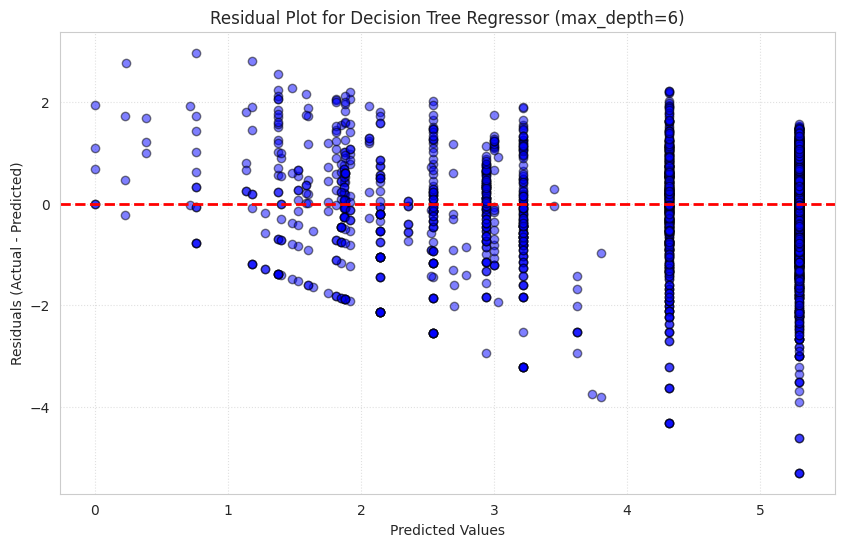

In [217]:
residuals = y_val - predict

# ---------------------------------------------------------
# 4. Plot the Residuals
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# Scatter plot of predicted values vs. residuals
plt.scatter(predict, residuals, alpha=0.5, color='blue', edgecolor='k')

# Add a horizontal line at 0 (ideal prediction)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Labels and Title
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot for Decision Tree Regressor (max_depth=6)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('../assignment_images/decision-tree-residual_plot.png', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

In [219]:
X = train.drop('count',axis=1)

In [221]:
missing_cols = set(X.columns) - set(test.columns)
for c in missing_cols:
    test[c] = False
test = test[X.columns]

In [223]:
test_predict = dt_reg.predict(test)

In [225]:
final_predict = np.exp(test_predict)

In [227]:
final_predict = np.round(final_predict)

In [229]:
final_predict

array([199., 199., 199., ...,  75., 199., 199.])

In [231]:
submission = pd.DataFrame()

In [233]:
temp_submission = pd.read_csv('../assignment_dataset/bike_test.csv')
submission['datetime'] = temp_submission['datetime']

In [235]:
submission['count_predicted'] = final_predict

In [237]:
submission.head()

,datetime,count_predicted
0,05-06-2012 5:00,199.0
1,19-03-2011 19:00,199.0
2,02-04-2012 6:00,199.0
3,13-07-2012 20:00,199.0
4,09-11-2011 19:00,13.0


In [248]:
submission.to_csv('../assignment_output/submission.csv',header=True,index=False)